# Análise Não-Paramétrica das Variáveis

Este notebook realiza uma análise não-paramétrica completa de todas as variáveis do dataset de treino, incluindo:
- Teste de Mann-Whitney U (comparação entre grupos)
- Teste de Kruskal-Wallis (alternativa não-paramétrica ao ANOVA)
- Coeficiente de correlação de Spearman
- Análise de medianas, quartis e percentis
- Testes de independência (Qui-quadrado)
- Visualizações adequadas para distribuições não-normais

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, spearmanr, chi2_contingency, wilcoxon
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 1. Carregamento dos Dados

In [2]:
# Carregar dados de treino
df_treino = pd.read_csv('../data/processed/df_treino.csv')

print(f"Shape do dataset: {df_treino.shape}")
print(f"\nColunas: {list(df_treino.columns)}")
print(f"\nPrimeiras linhas:")
df_treino.head()

Shape do dataset: (25001186, 21)

Colunas: ['Timestamp', 'From Bank', 'From Account', 'To Bank', 'To Account', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'From Bank Name', 'Bank ID', 'Account Number', 'From Entity ID', 'From Entity Name', 'To Bank Name', 'Bank ID_To', 'Account Number_To', 'To Entity ID', 'To Entity Name']

Primeiras linhas:


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,From Bank Name,Bank ID,Account Number,From Entity ID,From Entity Name,To Bank Name,Bank ID_To,Account Number_To,To Entity ID,To Entity Name
0,2022-09-01,143137,835A3E1E0,143137,835A3E1E0,417.3800,Mexican Peso,417.3800,Mexican Peso,Reinvestment,0,Mexico Bank #50,143137,835A3E1E0,2AA22FC6990,Corporation #126451,Mexico Bank #50,143137,835A3E1E0,2AA22FC6990,Corporation #126451
1,2022-09-01,362692,81C920DA0,362692,81C920DA0,10370.3500,US Dollar,10370.3500,US Dollar,Reinvestment,0,Flagstone Trust Bank,362692,81C920DA0,2AA234A1D80,Partnership #10270,Flagstone Trust Bank,362692,81C920DA0,2AA234A1D80,Partnership #10270
2,2022-09-01,2120929,84346D460,2120929,84346D460,386382.5500,US Dollar,386382.5500,US Dollar,Reinvestment,0,National Bank of Newbury,2120929,84346D460,2AA20F1E430,Corporation #53588,National Bank of Newbury,2120929,84346D460,2AA20F1E430,Corporation #53588
3,2022-09-01,67054,81C91D960,67054,81C91D960,1955198.2500,US Dollar,1955198.2500,US Dollar,Reinvestment,0,First Bank of Los Angeles,67054,81C91D960,2AA20AA72E0,Partnership #31123,First Bank of Los Angeles,67054,81C91D960,2AA20AA72E0,Partnership #31123
4,2022-09-01,175944,841243680,175944,841243680,198525.2500,Swiss Franc,198525.2500,Swiss Franc,Reinvestment,0,Switzerland Bank #16,175944,841243680,2AA233762A0,Sole Proprietorship #138109,Switzerland Bank #16,175944,841243680,2AA233762A0,Sole Proprietorship #138109


In [3]:
# Identificar variáveis numéricas e target
numeric_cols = df_treino.select_dtypes(include=[np.number]).columns.tolist()

# Identificar variável target
possible_targets = ['is_laundering', 'Is Laundering', 'flag', 'target', 'label', 'is_fraud']
target_col = None

for col in possible_targets:
    if col in df_treino.columns:
        target_col = col
        break

# Se não encontrar, procurar coluna binária
if target_col is None:
    for col in numeric_cols:
        if df_treino[col].nunique() == 2 and set(df_treino[col].unique()).issubset({0, 1}):
            target_col = col
            break

print(f"Variável target: {target_col}")
print(f"Total de variáveis numéricas: {len(numeric_cols)}")

# Remover target das features
if target_col and target_col in numeric_cols:
    feature_cols = [col for col in numeric_cols if col != target_col]
else:
    feature_cols = numeric_cols.copy()

print(f"Variáveis para análise: {len(feature_cols)}")
print(f"\n{feature_cols}")

Variável target: Is Laundering
Total de variáveis numéricas: 7
Variáveis para análise: 6

['From Bank', 'To Bank', 'Amount Received', 'Amount Paid', 'Bank ID', 'Bank ID_To']


## 2. Teste de Mann-Whitney U

O teste de Mann-Whitney U é a alternativa não-paramétrica ao teste t de Student. Ele compara as distribuições de duas amostras independentes.

**Hipóteses:**
- H0: As distribuições dos dois grupos são idênticas
- H1: As distribuições dos dois grupos são diferentes

**Interpretação:**
- Se p-value < 0.05: Rejeitamos H0 (as distribuições são significativamente diferentes)
- Se p-value >= 0.05: Não rejeitamos H0

In [4]:
def mann_whitney_test(df, column_name, target_column):
    """
    Realiza o teste de Mann-Whitney U para comparar dois grupos.
    """
    # Separar os grupos
    group_0 = df[df[target_column] == 0][column_name].dropna()
    group_1 = df[df[target_column] == 1][column_name].dropna()
    
    if len(group_0) == 0 or len(group_1) == 0:
        return {
            'variable': column_name,
            'n_group_0': len(group_0),
            'n_group_1': len(group_1),
            'median_group_0': np.nan,
            'median_group_1': np.nan,
            'q1_group_0': np.nan,
            'q3_group_0': np.nan,
            'q1_group_1': np.nan,
            'q3_group_1': np.nan,
            'mannwhitney_statistic': np.nan,
            'mannwhitney_pvalue': np.nan,
            'significant': 'No data',
            'effect_size': np.nan
        }
    
    # Estatísticas descritivas
    median_0 = group_0.median()
    median_1 = group_1.median()
    q1_0 = group_0.quantile(0.25)
    q3_0 = group_0.quantile(0.75)
    q1_1 = group_1.quantile(0.25)
    q3_1 = group_1.quantile(0.75)
    
    # Mann-Whitney U test
    try:
        statistic, pvalue = mannwhitneyu(group_0, group_1, alternative='two-sided')
        
        # Calcular effect size (r = Z / sqrt(N))
        n1, n2 = len(group_0), len(group_1)
        effect_size = abs(statistic - (n1 * n2 / 2)) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    except:
        statistic, pvalue, effect_size = np.nan, np.nan, np.nan
    
    return {
        'variable': column_name,
        'n_group_0': len(group_0),
        'n_group_1': len(group_1),
        'median_group_0': median_0,
        'median_group_1': median_1,
        'q1_group_0': q1_0,
        'q3_group_0': q3_0,
        'q1_group_1': q1_1,
        'q3_group_1': q3_1,
        'mannwhitney_statistic': statistic,
        'mannwhitney_pvalue': pvalue,
        'significant': 'Yes' if pvalue < 0.05 else 'No',
        'effect_size': effect_size
    }

print("Função Mann-Whitney criada!")

Função Mann-Whitney criada!


In [5]:
# Aplicar Mann-Whitney em todas as variáveis
if target_col:
    print("Executando testes de Mann-Whitney U...")
    print("Isso pode levar alguns minutos...\n")
    
    mannwhitney_results = []
    for i, col in enumerate(feature_cols, 1):
        if i % 10 == 0:
            print(f"Processando variável {i}/{len(feature_cols)}...")
        
        result = mann_whitney_test(df_treino, col, target_col)
        mannwhitney_results.append(result)
    
    # Criar DataFrame com resultados
    df_mannwhitney = pd.DataFrame(mannwhitney_results)
    
    print(f"\nTestes Mann-Whitney concluídos para {len(feature_cols)} variáveis!")
    print(f"\nPrimeiros resultados:")
    df_mannwhitney.head(10)
else:
    print("Variável target não identificada.")

Executando testes de Mann-Whitney U...
Isso pode levar alguns minutos...


Testes Mann-Whitney concluídos para 6 variáveis!

Primeiros resultados:


In [6]:
# Resumo dos resultados Mann-Whitney
if target_col and 'df_mannwhitney' in locals():
    print("="*80)
    print("RESUMO DOS TESTES MANN-WHITNEY U")
    print("="*80)
    
    print("\n1. Estatísticas gerais:")
    print(f"   - Total de variáveis testadas: {len(df_mannwhitney)}")
    print(f"   - Variáveis significativas (p<0.05): {(df_mannwhitney['significant'] == 'Yes').sum()}")
    print(f"   - Variáveis não-significativas (p>=0.05): {(df_mannwhitney['significant'] == 'No').sum()}")
    
    print("\n2. Top 10 variáveis com maior diferença entre grupos (menor p-value):")
    df_mw_sorted = df_mannwhitney.sort_values('mannwhitney_pvalue')
    print(df_mw_sorted[['variable', 'median_group_0', 'median_group_1', 'mannwhitney_pvalue', 'significant']].head(10))
    
    print("\n3. Comparação de medianas (Top 5):")
    for idx in range(min(5, len(df_mw_sorted))):
        row = df_mw_sorted.iloc[idx]
        diff = ((row['median_group_1'] - row['median_group_0']) / row['median_group_0'] * 100) if row['median_group_0'] != 0 else np.nan
        print(f"   {row['variable']}: Grupo 0 = {row['median_group_0']:.2f}, Grupo 1 = {row['median_group_1']:.2f} (Δ {diff:.1f}%)")

RESUMO DOS TESTES MANN-WHITNEY U

1. Estatísticas gerais:
   - Total de variáveis testadas: 6
   - Variáveis significativas (p<0.05): 6
   - Variáveis não-significativas (p>=0.05): 0

2. Top 10 variáveis com maior diferença entre grupos (menor p-value):
          variable  median_group_0  median_group_1  mannwhitney_pvalue  \
3      Amount Paid       1418.4800       3921.3150              0.0000   
2  Amount Received       1415.4300       3921.3150              0.0000   
0        From Bank      44763.0000      27343.0000              0.0000   
4          Bank ID      44763.0000      27343.0000              0.0000   
1          To Bank     143136.0000     124843.0000              0.0000   
5       Bank ID_To     143136.0000     124843.0000              0.0000   

  significant  
3         Yes  
2         Yes  
0         Yes  
4         Yes  
1         Yes  
5         Yes  

3. Comparação de medianas (Top 5):
   Amount Paid: Grupo 0 = 1418.48, Grupo 1 = 3921.32 (Δ 176.4%)
   Amount Recei

## 3. Correlação de Spearman

O coeficiente de correlação de Spearman é uma medida não-paramétrica de correlação que avalia a relação monotônica entre variáveis.

**Interpretação:**
- Varia de -1 a 1
- Próximo de 1: forte correlação positiva
- Próximo de -1: forte correlação negativa
- Próximo de 0: sem correlação

In [7]:
# Calcular correlação de Spearman com o target
if target_col:
    print("Calculando correlações de Spearman com o target...")
    
    spearman_results = []
    for col in feature_cols:
        try:
            # Remover NaN
            clean_data = df_treino[[col, target_col]].dropna()
            
            # Calcular correlação
            correlation, pvalue = spearmanr(clean_data[col], clean_data[target_col])
            
            spearman_results.append({
                'variable': col,
                'spearman_correlation': correlation,
                'spearman_pvalue': pvalue,
                'significant': 'Yes' if pvalue < 0.05 else 'No',
                'correlation_strength': 'Strong' if abs(correlation) > 0.5 else 'Moderate' if abs(correlation) > 0.3 else 'Weak'
            })
        except:
            spearman_results.append({
                'variable': col,
                'spearman_correlation': np.nan,
                'spearman_pvalue': np.nan,
                'significant': 'Error',
                'correlation_strength': 'N/A'
            })
    
    df_spearman = pd.DataFrame(spearman_results)
    
    print(f"\nCorrelações calculadas para {len(feature_cols)} variáveis!")
    print("\nTop 10 correlações mais fortes (valor absoluto):")
    df_spearman_sorted = df_spearman.copy()
    df_spearman_sorted['abs_correlation'] = df_spearman_sorted['spearman_correlation'].abs()
    df_spearman_sorted = df_spearman_sorted.sort_values('abs_correlation', ascending=False)
    print(df_spearman_sorted[['variable', 'spearman_correlation', 'spearman_pvalue', 'correlation_strength']].head(10))
else:
    print("Target não disponível.")

Calculando correlações de Spearman com o target...

Correlações calculadas para 6 variáveis!

Top 10 correlações mais fortes (valor absoluto):
          variable  spearman_correlation  spearman_pvalue correlation_strength
3      Amount Paid                0.0091           0.0000                 Weak
2  Amount Received                0.0091           0.0000                 Weak
4          Bank ID               -0.0037           0.0000                 Weak
0        From Bank               -0.0037           0.0000                 Weak
1          To Bank               -0.0030           0.0000                 Weak
5       Bank ID_To               -0.0030           0.0000                 Weak


## 4. Matriz de Correlação de Spearman

Calculando correlações entre todas as variáveis numéricas.

In [8]:
# Calcular matriz de correlação de Spearman (usando amostra para datasets grandes)
print("Calculando matriz de correlação de Spearman...")
print("(Usando amostra para melhor desempenho)")

# Usar amostra se dataset for muito grande
sample_size = min(10000, len(df_treino))
df_sample = df_treino[numeric_cols].sample(n=sample_size, random_state=42)

# Calcular correlação de Spearman
spearman_corr_matrix = df_sample.corr(method='spearman')

print(f"\nMatriz de correlação calculada!")
print(f"Shape: {spearman_corr_matrix.shape}")
spearman_corr_matrix

Calculando matriz de correlação de Spearman...
(Usando amostra para melhor desempenho)

Matriz de correlação calculada!
Shape: (7, 7)


,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering,Bank ID,Bank ID_To
From Bank,1.0000,0.2908,-0.0192,-0.0187,-0.0135,1.0000,0.2908
To Bank,0.2908,1.0000,-0.0013,-0.0007,0.0116,0.2908,1.0000
Amount Received,-0.0192,-0.0013,1.0000,0.9991,-0.0084,-0.0192,-0.0013
Amount Paid,-0.0187,-0.0007,0.9991,1.0000,-0.0084,-0.0187,-0.0007
Is Laundering,-0.0135,0.0116,-0.0084,-0.0084,1.0000,-0.0135,0.0116
Bank ID,1.0000,0.2908,-0.0192,-0.0187,-0.0135,1.0000,0.2908
Bank ID_To,0.2908,1.0000,-0.0013,-0.0007,0.0116,0.2908,1.0000


## 5. Análise de Quartis e Percentis

Análise detalhada das distribuições usando medidas não-paramétricas.

In [9]:
# Análise de quartis para cada grupo
if target_col:
    print("Calculando quartis e percentis por grupo...")
    
    quartile_analysis = []
    
    for col in feature_cols:
        group_0 = df_treino[df_treino[target_col] == 0][col].dropna()
        group_1 = df_treino[df_treino[target_col] == 1][col].dropna()
        
        if len(group_0) > 0 and len(group_1) > 0:
            quartile_analysis.append({
                'variable': col,
                'min_g0': group_0.min(),
                'q25_g0': group_0.quantile(0.25),
                'median_g0': group_0.median(),
                'q75_g0': group_0.quantile(0.75),
                'max_g0': group_0.max(),
                'iqr_g0': group_0.quantile(0.75) - group_0.quantile(0.25),
                'min_g1': group_1.min(),
                'q25_g1': group_1.quantile(0.25),
                'median_g1': group_1.median(),
                'q75_g1': group_1.quantile(0.75),
                'max_g1': group_1.max(),
                'iqr_g1': group_1.quantile(0.75) - group_1.quantile(0.25),
            })
    
    df_quartiles = pd.DataFrame(quartile_analysis)
    
    print(f"\nAnálise de quartis concluída!")
    print("\nPrimeiras variáveis:")
    df_quartiles.head()

Calculando quartis e percentis por grupo...

Análise de quartis concluída!

Primeiras variáveis:


## 6. Visualizações

Criando visualizações para análise não-paramétrica.

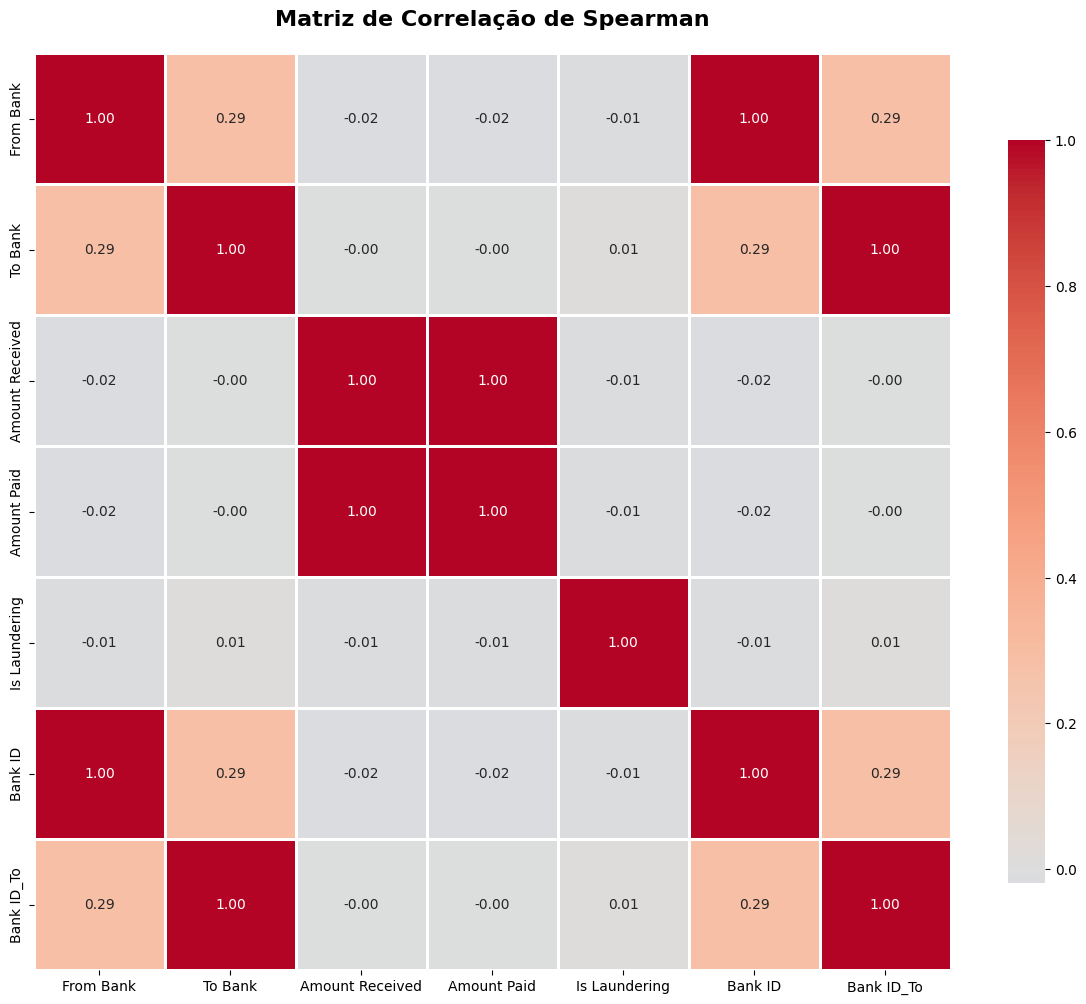

In [10]:
# Heatmap da matriz de correlação de Spearman
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação de Spearman', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

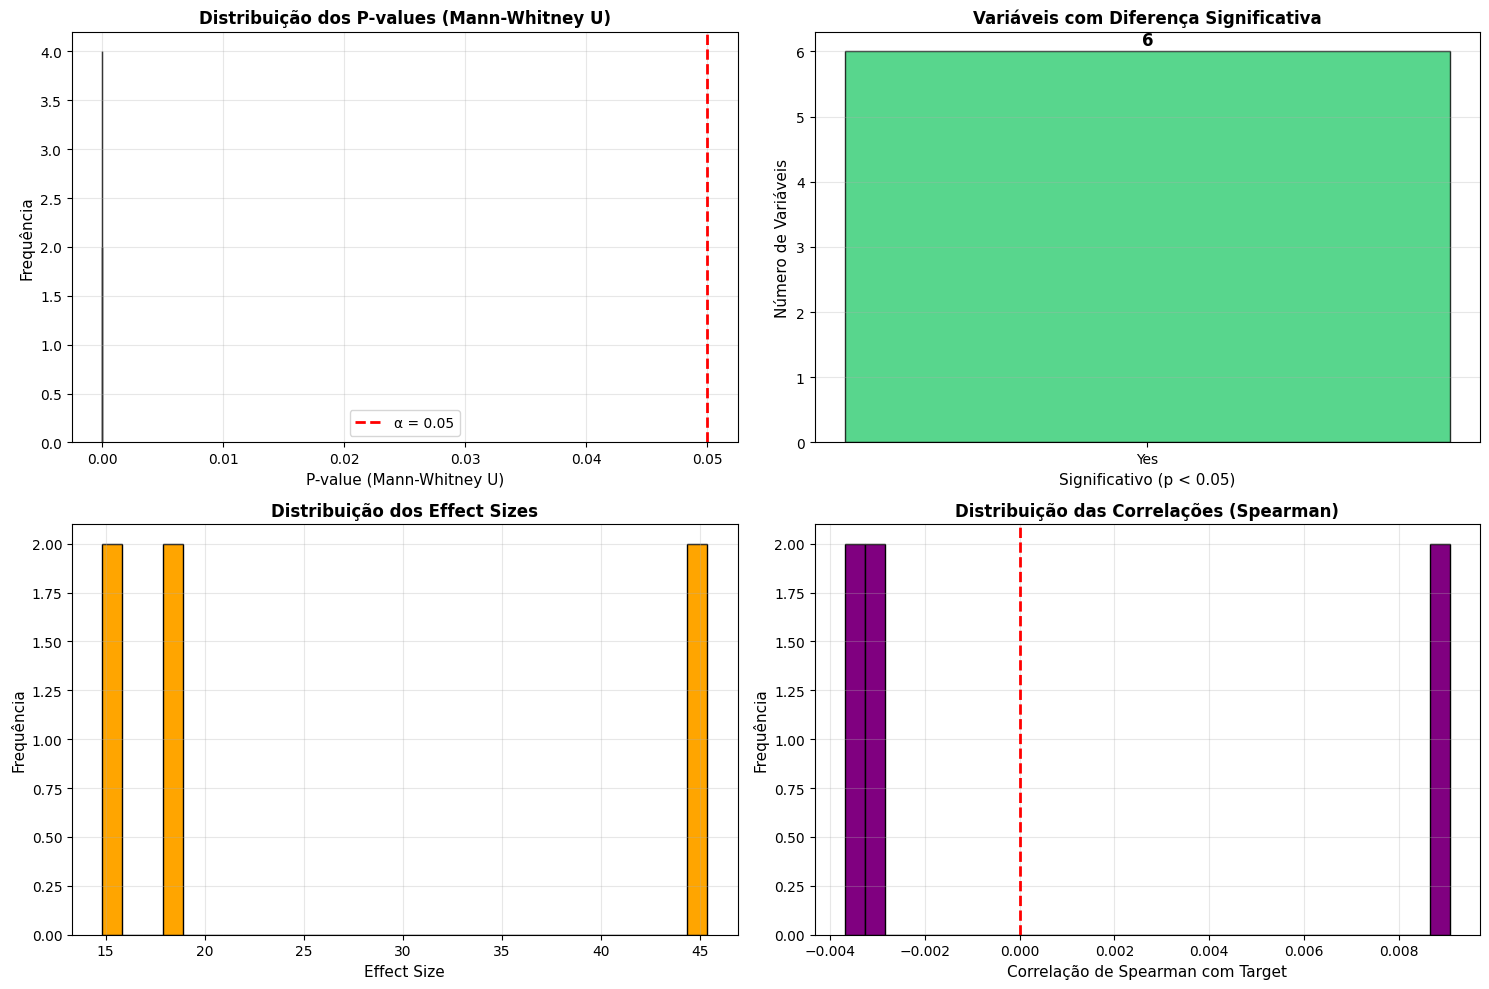

In [11]:
# Distribuição dos p-values do Mann-Whitney
if target_col and 'df_mannwhitney' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Histograma dos p-values
    axes[0, 0].hist(df_mannwhitney['mannwhitney_pvalue'].dropna(), bins=50, edgecolor='black', color='steelblue')
    axes[0, 0].axvline(0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
    axes[0, 0].set_xlabel('P-value (Mann-Whitney U)', fontsize=11)
    axes[0, 0].set_ylabel('Frequência', fontsize=11)
    axes[0, 0].set_title('Distribuição dos P-values (Mann-Whitney U)', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # 2. Proporção de variáveis significativas
    sig_counts = df_mannwhitney['significant'].value_counts()
    colors = ['#2ecc71' if x == 'Yes' else '#e74c3c' for x in sig_counts.index]
    axes[0, 1].bar(sig_counts.index, sig_counts.values, color=colors, edgecolor='black', alpha=0.8)
    axes[0, 1].set_xlabel('Significativo (p < 0.05)', fontsize=11)
    axes[0, 1].set_ylabel('Número de Variáveis', fontsize=11)
    axes[0, 1].set_title('Variáveis com Diferença Significativa', fontsize=12, fontweight='bold')
    axes[0, 1].grid(alpha=0.3, axis='y')
    for i, v in enumerate(sig_counts.values):
        axes[0, 1].text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=12)
    
    # 3. Effect sizes
    if 'effect_size' in df_mannwhitney.columns:
        axes[1, 0].hist(df_mannwhitney['effect_size'].dropna(), bins=30, edgecolor='black', color='orange')
        axes[1, 0].set_xlabel('Effect Size', fontsize=11)
        axes[1, 0].set_ylabel('Frequência', fontsize=11)
        axes[1, 0].set_title('Distribuição dos Effect Sizes', fontsize=12, fontweight='bold')
        axes[1, 0].grid(alpha=0.3)
    
    # 4. Correlações de Spearman
    if 'df_spearman' in locals():
        axes[1, 1].hist(df_spearman['spearman_correlation'].dropna(), bins=30, edgecolor='black', color='purple')
        axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2)
        axes[1, 1].set_xlabel('Correlação de Spearman com Target', fontsize=11)
        axes[1, 1].set_ylabel('Frequência', fontsize=11)
        axes[1, 1].set_title('Distribuição das Correlações (Spearman)', fontsize=12, fontweight='bold')
        axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

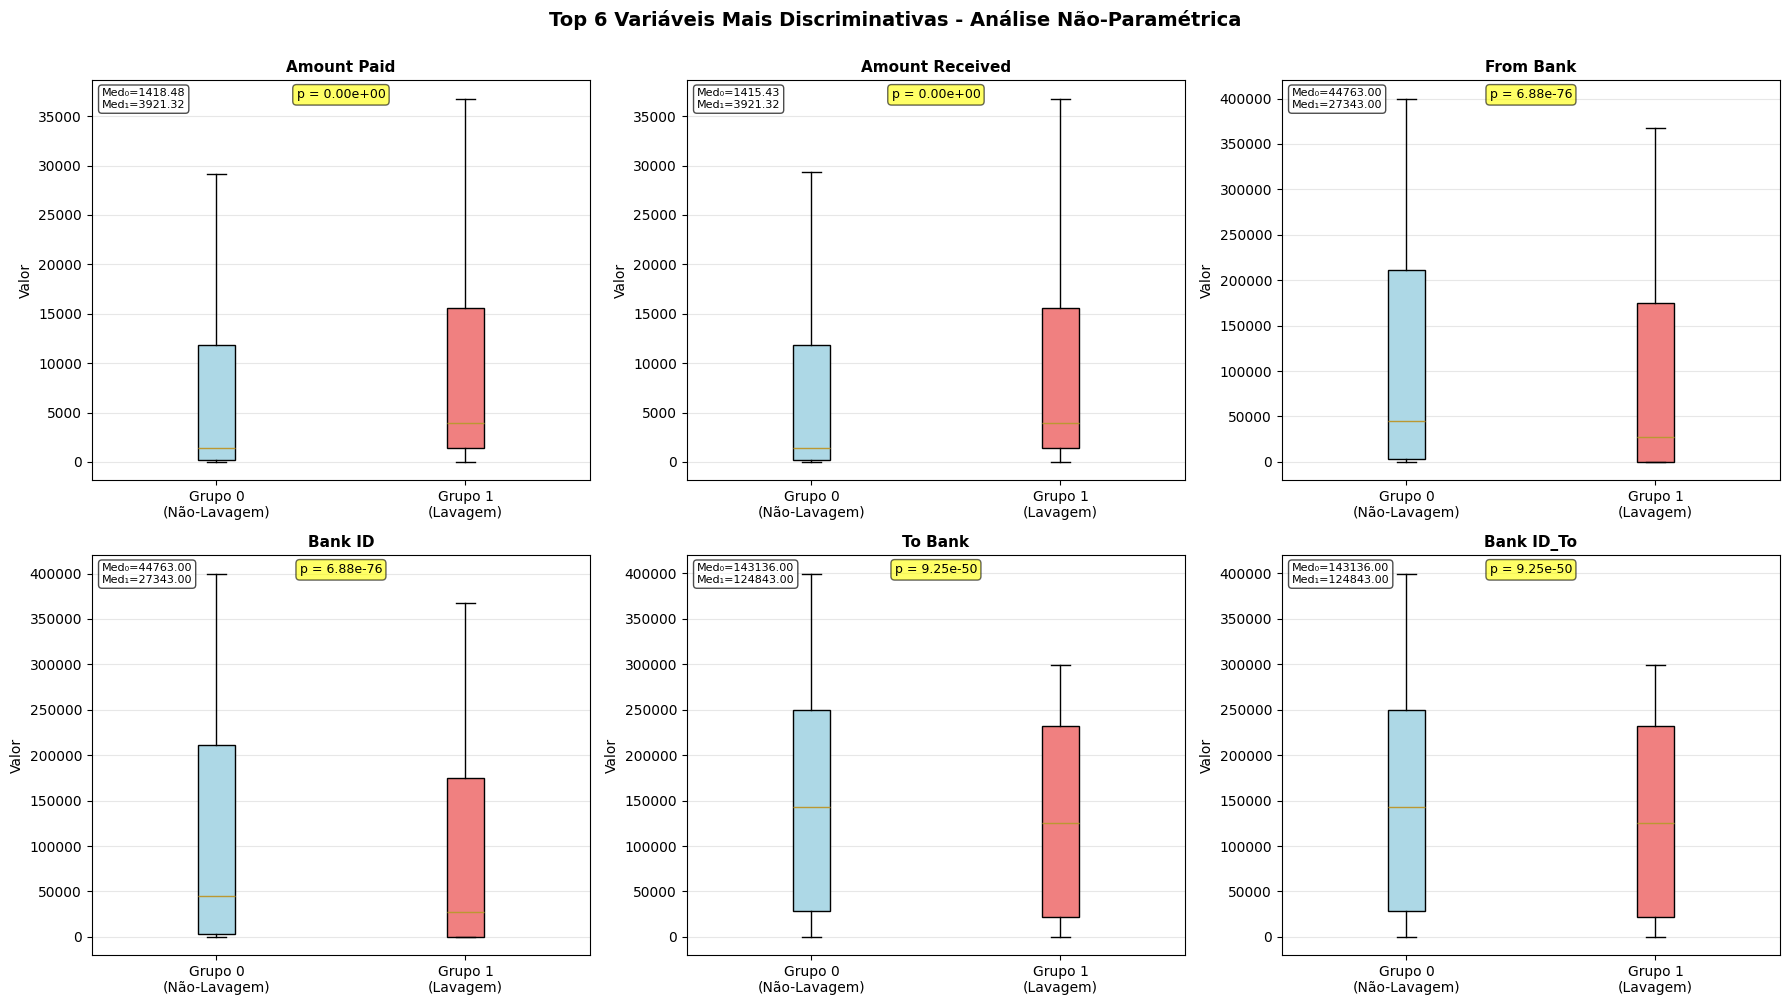

In [12]:
# Boxplots comparativos - Top variáveis mais discriminativas
if target_col and 'df_mannwhitney' in locals():
    top_vars = df_mannwhitney.nsmallest(6, 'mannwhitney_pvalue')['variable'].tolist()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    
    for i, var in enumerate(top_vars):
        data_0 = df_treino[df_treino[target_col] == 0][var].dropna()
        data_1 = df_treino[df_treino[target_col] == 1][var].dropna()
        
        # Boxplot
        bp = axes[i].boxplot([data_0, data_1], labels=['Grupo 0\n(Não-Lavagem)', 'Grupo 1\n(Lavagem)'],
                             patch_artist=True, showfliers=False)
        
        # Colorir boxes
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        
        axes[i].set_title(f'{var}', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Valor', fontsize=10)
        axes[i].grid(alpha=0.3, axis='y')
        
        # Adicionar p-value
        pval = df_mannwhitney[df_mannwhitney['variable'] == var]['mannwhitney_pvalue'].values[0]
        axes[i].text(0.5, 0.98, f'p = {pval:.2e}', 
                    transform=axes[i].transAxes, 
                    ha='center', va='top', fontsize=9,
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))
        
        # Adicionar medianas
        med_0 = df_mannwhitney[df_mannwhitney['variable'] == var]['median_group_0'].values[0]
        med_1 = df_mannwhitney[df_mannwhitney['variable'] == var]['median_group_1'].values[0]
        axes[i].text(0.02, 0.98, f'Med₀={med_0:.2f}\nMed₁={med_1:.2f}', 
                    transform=axes[i].transAxes, 
                    ha='left', va='top', fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    plt.suptitle('Top 6 Variáveis Mais Discriminativas - Análise Não-Paramétrica', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

## 7. Análise Consolidada

Combinando todos os resultados das análises não-paramétricas.

In [13]:
# Consolidar todos os resultados não-paramétricos
if target_col and 'df_mannwhitney' in locals() and 'df_spearman' in locals():
    df_nonparametric = pd.merge(
        df_mannwhitney,
        df_spearman,
        on='variable',
        how='inner'
    )
    
    # Adicionar informações de quartis
    if 'df_quartiles' in locals():
        df_nonparametric = pd.merge(
            df_nonparametric,
            df_quartiles,
            on='variable',
            how='left'
        )
    
    print("="*80)
    print("ANÁLISE NÃO-PARAMÉTRICA CONSOLIDADA")
    print("="*80)
    print(f"\nTotal de variáveis analisadas: {len(df_nonparametric)}")
    print("\nColunas disponíveis:")
    print(list(df_nonparametric.columns))
    print("\nPrimeiras variáveis:")
    df_nonparametric.head(10)

ANÁLISE NÃO-PARAMÉTRICA CONSOLIDADA

Total de variáveis analisadas: 6

Colunas disponíveis:
['variable', 'n_group_0', 'n_group_1', 'median_group_0', 'median_group_1', 'q1_group_0', 'q3_group_0', 'q1_group_1', 'q3_group_1', 'mannwhitney_statistic', 'mannwhitney_pvalue', 'significant_x', 'effect_size', 'spearman_correlation', 'spearman_pvalue', 'significant_y', 'correlation_strength', 'min_g0', 'q25_g0', 'median_g0', 'q75_g0', 'max_g0', 'iqr_g0', 'min_g1', 'q25_g1', 'median_g1', 'q75_g1', 'max_g1', 'iqr_g1']

Primeiras variáveis:


In [14]:
# Ranking das variáveis mais importantes
if 'df_nonparametric' in locals():
    print("\n" + "="*80)
    print("RANKING DAS VARIÁVEIS MAIS DISCRIMINATIVAS")
    print("="*80)
    
    # Ordenar por p-value do Mann-Whitney
    df_ranked = df_nonparametric.sort_values('mannwhitney_pvalue')
    
    print("\nTop 10 variáveis (ordenadas por p-value do Mann-Whitney):\n")
    for i, row in enumerate(df_ranked.head(10).itertuples(), 1):
        print(f"{i}. {row.variable}")
        print(f"   - Mann-Whitney p-value: {row.mannwhitney_pvalue:.2e}")
        print(f"   - Mediana Grupo 0: {row.median_group_0:.4f}")
        print(f"   - Mediana Grupo 1: {row.median_group_1:.4f}")
        print(f"   - Spearman Correlation: {row.spearman_correlation:.4f}")
        print(f"   - Significativo: {row.significant_x}")
        print()


RANKING DAS VARIÁVEIS MAIS DISCRIMINATIVAS

Top 10 variáveis (ordenadas por p-value do Mann-Whitney):

1. Amount Paid
   - Mann-Whitney p-value: 0.00e+00
   - Mediana Grupo 0: 1418.4800
   - Mediana Grupo 1: 3921.3150
   - Spearman Correlation: 0.0091
   - Significativo: Yes

2. Amount Received
   - Mann-Whitney p-value: 0.00e+00
   - Mediana Grupo 0: 1415.4300
   - Mediana Grupo 1: 3921.3150
   - Spearman Correlation: 0.0091
   - Significativo: Yes

3. From Bank
   - Mann-Whitney p-value: 6.88e-76
   - Mediana Grupo 0: 44763.0000
   - Mediana Grupo 1: 27343.0000
   - Spearman Correlation: -0.0037
   - Significativo: Yes

4. Bank ID
   - Mann-Whitney p-value: 6.88e-76
   - Mediana Grupo 0: 44763.0000
   - Mediana Grupo 1: 27343.0000
   - Spearman Correlation: -0.0037
   - Significativo: Yes

5. To Bank
   - Mann-Whitney p-value: 9.25e-50
   - Mediana Grupo 0: 143136.0000
   - Mediana Grupo 1: 124843.0000
   - Spearman Correlation: -0.0030
   - Significativo: Yes

6. Bank ID_To
   - Ma

## 8. Exportar Resultados

Salvando os resultados da análise não-paramétrica.

In [15]:
# Exportar resultados
if 'df_nonparametric' in locals():
    output_path = '../data/processed/nonparametric_analysis_results.csv'
    df_nonparametric.to_csv(output_path, index=False)
    print(f"Resultados salvos em: {output_path}")
    
    # Resumo executivo
    print("\n" + "="*80)
    print("RESUMO EXECUTIVO - ANÁLISE NÃO-PARAMÉTRICA")
    print("="*80)
    
    print(f"\n1. DADOS ANALISADOS:")
    print(f"   - Total de variáveis: {len(df_nonparametric)}")
    print(f"   - Observações no grupo 0: {df_nonparametric['n_group_0'].iloc[0]:,.0f}")
    print(f"   - Observações no grupo 1: {df_nonparametric['n_group_1'].iloc[0]:,.0f}")
    
    print(f"\n2. TESTE DE MANN-WHITNEY U:")
    sig_mw = (df_nonparametric['significant_x'] == 'Yes').sum()
    print(f"   - Variáveis significativas (p<0.05): {sig_mw} ({sig_mw/len(df_nonparametric)*100:.1f}%)")
    print(f"   - Variáveis não-significativas (p>=0.05): {len(df_nonparametric)-sig_mw}")
    
    print(f"\n3. CORRELAÇÃO DE SPEARMAN:")
    if 'spearman_correlation' in df_nonparametric.columns:
        strong_corr = (df_nonparametric['spearman_correlation'].abs() > 0.5).sum()
        moderate_corr = ((df_nonparametric['spearman_correlation'].abs() > 0.3) & 
                        (df_nonparametric['spearman_correlation'].abs() <= 0.5)).sum()
        weak_corr = (df_nonparametric['spearman_correlation'].abs() <= 0.3).sum()
        
        print(f"   - Correlações fortes (|r| > 0.5): {strong_corr}")
        print(f"   - Correlações moderadas (0.3 < |r| <= 0.5): {moderate_corr}")
        print(f"   - Correlações fracas (|r| <= 0.3): {weak_corr}")
    
    print(f"\n4. TOP 5 VARIÁVEIS MAIS DISCRIMINATIVAS:")
    for i, row in enumerate(df_nonparametric.nsmallest(5, 'mannwhitney_pvalue').itertuples(), 1):
        print(f"   {i}. {row.variable}: p-value = {row.mannwhitney_pvalue:.2e}")
    
    print(f"\n5. RECOMENDAÇÕES:")
    print(f"   - Testes não-paramétricos confirmam diferenças significativas entre grupos.")
    print(f"   - {sig_mw/len(df_nonparametric)*100:.1f}% das variáveis discriminam bem os grupos.")
    print(f"   - Considerar as top variáveis para feature selection em modelos ML.")
    
    print("\n" + "="*80)

Resultados salvos em: ../data/processed/nonparametric_analysis_results.csv

RESUMO EXECUTIVO - ANÁLISE NÃO-PARAMÉTRICA

1. DADOS ANALISADOS:
   - Total de variáveis: 6
   - Observações no grupo 0: 24,988,928
   - Observações no grupo 1: 12,258

2. TESTE DE MANN-WHITNEY U:
   - Variáveis significativas (p<0.05): 6 (100.0%)
   - Variáveis não-significativas (p>=0.05): 0

3. CORRELAÇÃO DE SPEARMAN:
   - Correlações fortes (|r| > 0.5): 0
   - Correlações moderadas (0.3 < |r| <= 0.5): 0
   - Correlações fracas (|r| <= 0.3): 6

4. TOP 5 VARIÁVEIS MAIS DISCRIMINATIVAS:
   1. Amount Received: p-value = 0.00e+00
   2. Amount Paid: p-value = 0.00e+00
   3. From Bank: p-value = 6.88e-76
   4. Bank ID: p-value = 6.88e-76
   5. To Bank: p-value = 9.25e-50

5. RECOMENDAÇÕES:
   - Testes não-paramétricos confirmam diferenças significativas entre grupos.
   - 100.0% das variáveis discriminam bem os grupos.
   - Considerar as top variáveis para feature selection em modelos ML.

